# 🏦 Roth Conversion Optimizer

## 📝 Enter Your Household Data Below, Then Click "Run All"

In [1]:
# =============================================================================
# 📝 ENTER YOUR HOUSEHOLD DATA HERE
# =============================================================================

# --- SPOUSE 1 (You) ---
SPOUSE1_NAME = "Rajesh"
SPOUSE1_AGE = 60
SPOUSE1_RETIREMENT_AGE = 65           # Age you plan to retire / stop working
SPOUSE1_TRADITIONAL_IRA = 831_211      # Traditional IRA balance
SPOUSE1_SEP_IRA = 88_152               # SEP-IRA balance
SPOUSE1_ROTH_IRA = 0                  # Roth IRA balance
SPOUSE1_SS_START_AGE = 67             # Age you'll start Social Security (62-70)
SPOUSE1_SS_ANNUAL_BENEFIT = 58_860    # Expected ANNUAL SS benefit at start age (from ssa.gov)

# --- SPOUSE 2 (Wife) ---
SPOUSE2_NAME = "Terri"
SPOUSE2_AGE = 61
SPOUSE2_RETIREMENT_AGE = 70           # Age spouse plans to retire
SPOUSE2_TRADITIONAL_IRA = 1_587_530     # Traditional IRA balance
SPOUSE2_SEP_IRA = 274_116              # SEP-IRA balance
SPOUSE2_ROTH_IRA = 0                  # Roth IRA balance
SPOUSE2_SS_START_AGE = 70             # Age spouse will start Social Security
SPOUSE2_SS_ANNUAL_BENEFIT = 27_996    # Expected ANNUAL SS benefit at start age (from ssa.gov)

# --- JOINT ACCOUNTS ---
JOINT_TAXABLE_ACCOUNTS = 439_514       # After-tax brokerage, savings, etc.

# --- CURRENT INCOME SOURCES (annual amounts while working) ---
CURRENT_WORK_INCOME = 0               # Current annual wages/self-employment (0 if retired)
PENSION_INCOME = 0                    # Annual pension income (if any)
OTHER_INCOME = 0                      # Other income (rental, dividends, etc.)

# --- TAX & PLANNING PARAMETERS ---
STATE_TAX_RATE = 0.04                 # State tax rate (0 for no state tax)
EXPECTED_RETURN = 0.06                # Expected annual return (6% = 0.06)
INFLATION_RATE = 0.025                # Expected inflation (2.5% = 0.025)
TARGET_BRACKET = 0.22                 # Target bracket to fill (10%, 12%, 22%, 24%, 32%, 35%)

# =============================================================================
# Calculate values (annual is used directly, monthly calculated for display)
SPOUSE1_SS_ANNUAL = SPOUSE1_SS_ANNUAL_BENEFIT
SPOUSE2_SS_ANNUAL = SPOUSE2_SS_ANNUAL_BENEFIT
SPOUSE1_SS_MONTHLY = SPOUSE1_SS_ANNUAL / 12
SPOUSE2_SS_MONTHLY = SPOUSE2_SS_ANNUAL / 12

print("✓ Data entered!")
print(f"\n{SPOUSE1_NAME}: Retire at {SPOUSE1_RETIREMENT_AGE}, SS starts at {SPOUSE1_SS_START_AGE}")
print(f"  Annual: ${SPOUSE1_SS_ANNUAL:,.0f}  (${SPOUSE1_SS_MONTHLY:,.0f}/month)")
print(f"{SPOUSE2_NAME}: Retire at {SPOUSE2_RETIREMENT_AGE}, SS starts at {SPOUSE2_SS_START_AGE}")
print(f"  Annual: ${SPOUSE2_SS_ANNUAL:,.0f}  (${SPOUSE2_SS_MONTHLY:,.0f}/month)")
print(f"\nNow click 'Run All' or run remaining cells.")

✓ Data entered!

Rajesh: Retire at 65, SS starts at 67
  Annual: $58,860  ($4,905/month)
Terri: Retire at 70, SS starts at 70
  Annual: $27,996  ($2,333/month)

Now click 'Run All' or run remaining cells.


In [2]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2024-2025 Federal Tax Brackets
We'll use the 2024 tax brackets (adjusted for inflation) as a baseline.

In [3]:
# 2024 Federal Tax Brackets (Married Filing Jointly)
# Each tuple: (upper_limit, rate)
TAX_BRACKETS_MFJ_2024 = [
    (23200, 0.10),
    (94300, 0.12),
    (201050, 0.22),
    (383900, 0.24),
    (487450, 0.32),
    (731200, 0.35),
    (float('inf'), 0.37)
]

# 2024 Federal Tax Brackets (Single)
TAX_BRACKETS_SINGLE_2024 = [
    (11600, 0.10),
    (47150, 0.12),
    (100525, 0.22),
    (191950, 0.24),
    (243725, 0.32),
    (609350, 0.35),
    (float('inf'), 0.37)
]

# Standard Deductions for 2024
STANDARD_DEDUCTION_MFJ_2024 = 29200
STANDARD_DEDUCTION_SINGLE_2024 = 14600
STANDARD_DEDUCTION_65_PLUS_ADDITION = 1550  # Additional for 65+ (per person)

print("Tax brackets loaded for 2024")

Tax brackets loaded for 2024


In [4]:
@dataclass
class SpouseAccounts:
    """Individual spouse's retirement accounts and income timing."""
    name: str
    age: int
    traditional_ira: float = 0.0      # Traditional IRA balance
    sep_ira: float = 0.0              # SEP-IRA balance
    roth_ira: float = 0.0             # Roth IRA balance
    retirement_age: int = 65          # Age planning to retire
    ss_start_age: int = 67            # Age to start Social Security
    ss_annual_benefit: float = 0.0    # Annual SS benefit at start age
    
    @property
    def total_pretax(self) -> float:
        """Total pre-tax retirement accounts (subject to conversion/RMDs)."""
        return self.traditional_ira + self.sep_ira
    
    @property
    def total_roth(self) -> float:
        """Total Roth accounts."""
        return self.roth_ira
    
    def is_retired(self, year: int) -> bool:
        """Check if spouse is retired in given year."""
        return self.age + year >= self.retirement_age
    
    def is_collecting_ss(self, year: int) -> bool:
        """Check if spouse is collecting Social Security in given year."""
        return self.age + year >= self.ss_start_age
    
    def get_ss_income(self, year: int, inflation_rate: float = 0.025) -> float:
        """Get Social Security income for given year (with COLA adjustment)."""
        if not self.is_collecting_ss(year):
            return 0.0
        # Apply COLA from SS start age
        years_collecting = (self.age + year) - self.ss_start_age
        return self.ss_annual_benefit * ((1 + inflation_rate) ** years_collecting)


@dataclass 
class HouseholdProfile:
    """Complete household profile for married couple Roth conversion planning."""
    # Spouse information
    spouse1: SpouseAccounts
    spouse2: SpouseAccounts
    
    # Joint/Household information
    joint_taxable_accounts: float = 0.0    # After-tax brokerage accounts
    
    # Income sources (annual amounts)
    work_income: float = 0.0               # Current work income (wages, self-employment)
    pension_income: float = 0.0            # Combined pension income
    other_income: float = 0.0              # Other taxable income (rental, dividends, etc.)
    
    # Tax and planning parameters
    state_tax_rate: float = 0.0            # State income tax rate
    expected_return: float = 0.06          # Expected investment return
    inflation_rate: float = 0.025          # Expected inflation
    target_bracket: float = 0.22           # Target tax bracket to fill
    
    @property
    def total_pretax(self) -> float:
        """Total household pre-tax retirement accounts."""
        return self.spouse1.total_pretax + self.spouse2.total_pretax
    
    @property
    def total_roth(self) -> float:
        """Total household Roth accounts."""
        return self.spouse1.total_roth + self.spouse2.total_roth
    
    def get_income_for_year(self, year: int) -> Dict[str, float]:
        """Get all income sources for a specific year."""
        inflation_factor = (1 + self.inflation_rate) ** year
        
        # Work income stops at retirement (use earlier retirement age)
        both_retired = self.spouse1.is_retired(year) and self.spouse2.is_retired(year)
        work = 0 if both_retired else self.work_income * inflation_factor
        
        # Social Security (each spouse may start at different times)
        ss1 = self.spouse1.get_ss_income(year, self.inflation_rate)
        ss2 = self.spouse2.get_ss_income(year, self.inflation_rate)
        
        # Other income (inflation adjusted)
        pension = self.pension_income * inflation_factor
        other = self.other_income * inflation_factor
        
        return {
            'work_income': work,
            'spouse1_ss': ss1,
            'spouse2_ss': ss2,
            'total_ss': ss1 + ss2,
            'pension': pension,
            'other': other
        }
    
    def get_taxable_income_for_year(self, year: int) -> float:
        """Get total taxable income for a year (excluding conversions)."""
        income = self.get_income_for_year(year)
        
        # Social Security is partially taxable (85% for higher incomes)
        ss_taxable = 0.85 * income['total_ss']
        
        return income['work_income'] + ss_taxable + income['pension'] + income['other']
    
    @property
    def total_taxable_income(self) -> float:
        """Total current taxable income (for backward compatibility)."""
        return self.get_taxable_income_for_year(0)
    
    def get_standard_deduction(self, year: int = 0) -> float:
        """Calculate standard deduction for MFJ based on ages."""
        inflation_factor = (1 + self.inflation_rate) ** year
        
        base = STANDARD_DEDUCTION_MFJ_2024
        extra = 0
        
        # Add extra deduction for each spouse 65+
        if self.spouse1.age + year >= 65:
            extra += STANDARD_DEDUCTION_65_PLUS_ADDITION
        if self.spouse2.age + year >= 65:
            extra += STANDARD_DEDUCTION_65_PLUS_ADDITION
        
        return (base + extra) * inflation_factor
    
    def get_tax_brackets(self, year: int = 0) -> List[Tuple[float, float]]:
        """Get inflation-adjusted tax brackets for MFJ."""
        inflation_factor = (1 + self.inflation_rate) ** year
        
        adjusted_brackets = []
        for limit, rate in TAX_BRACKETS_MFJ_2024:
            if limit == float('inf'):
                adjusted_brackets.append((limit, rate))
            else:
                adjusted_brackets.append((limit * inflation_factor, rate))
        
        return adjusted_brackets


# Legacy single-person profile for backward compatibility
@dataclass
class TaxpayerProfile:
    """Profile containing taxpayer information for Roth conversion planning."""
    name: str
    age: int
    filing_status: str  # 'single' or 'mfj' (married filing jointly)
    traditional_ira_balance: float
    roth_ira_balance: float
    other_taxable_income: float  # Social Security, pensions, wages, etc.
    state_tax_rate: float  # State income tax rate (0 for no state tax)
    expected_return: float  # Expected annual investment return
    inflation_rate: float  # Expected inflation rate
    target_bracket: float  # Target marginal tax bracket to fill (e.g., 0.22)
    spouse_age: Optional[int] = None  # For MFJ, spouse's age
    
    def get_standard_deduction(self, year: int = 0) -> float:
        """Calculate standard deduction based on filing status and age."""
        inflation_factor = (1 + self.inflation_rate) ** year
        
        if self.filing_status == 'mfj':
            base = STANDARD_DEDUCTION_MFJ_2024
            extra = 0
            if self.age + year >= 65:
                extra += STANDARD_DEDUCTION_65_PLUS_ADDITION
            if self.spouse_age and self.spouse_age + year >= 65:
                extra += STANDARD_DEDUCTION_65_PLUS_ADDITION
        else:
            base = STANDARD_DEDUCTION_SINGLE_2024
            extra = STANDARD_DEDUCTION_65_PLUS_ADDITION if self.age + year >= 65 else 0
        
        return (base + extra) * inflation_factor
    
    def get_tax_brackets(self, year: int = 0) -> List[Tuple[float, float]]:
        """Get inflation-adjusted tax brackets."""
        inflation_factor = (1 + self.inflation_rate) ** year
        base_brackets = TAX_BRACKETS_MFJ_2024 if self.filing_status == 'mfj' else TAX_BRACKETS_SINGLE_2024
        
        adjusted_brackets = []
        for limit, rate in base_brackets:
            if limit == float('inf'):
                adjusted_brackets.append((limit, rate))
            else:
                adjusted_brackets.append((limit * inflation_factor, rate))
        
        return adjusted_brackets


# =============================================================================
# BUILD HOUSEHOLD FROM YOUR INPUT DATA
# =============================================================================

spouse1 = SpouseAccounts(
    name=SPOUSE1_NAME,
    age=SPOUSE1_AGE,
    traditional_ira=SPOUSE1_TRADITIONAL_IRA,
    sep_ira=SPOUSE1_SEP_IRA,
    roth_ira=SPOUSE1_ROTH_IRA,
    retirement_age=SPOUSE1_RETIREMENT_AGE,
    ss_start_age=SPOUSE1_SS_START_AGE,
    ss_annual_benefit=SPOUSE1_SS_ANNUAL,
)

spouse2 = SpouseAccounts(
    name=SPOUSE2_NAME,
    age=SPOUSE2_AGE,
    traditional_ira=SPOUSE2_TRADITIONAL_IRA,
    sep_ira=SPOUSE2_SEP_IRA,
    roth_ira=SPOUSE2_ROTH_IRA,
    retirement_age=SPOUSE2_RETIREMENT_AGE,
    ss_start_age=SPOUSE2_SS_START_AGE,
    ss_annual_benefit=SPOUSE2_SS_ANNUAL,
)

household = HouseholdProfile(
    spouse1=spouse1,
    spouse2=spouse2,
    joint_taxable_accounts=JOINT_TAXABLE_ACCOUNTS,
    work_income=CURRENT_WORK_INCOME,
    pension_income=PENSION_INCOME,
    other_income=OTHER_INCOME,
    state_tax_rate=STATE_TAX_RATE,
    expected_return=EXPECTED_RETURN,
    inflation_rate=INFLATION_RATE,
    target_bracket=TARGET_BRACKET,
)

# Display summary
print("=" * 70)
print("HOUSEHOLD RETIREMENT ACCOUNT SUMMARY")
print("=" * 70)
print(f"\n{spouse1.name} (Age {spouse1.age}):")
print(f"  Traditional IRA:    ${spouse1.traditional_ira:>12,.0f}")
print(f"  SEP-IRA:            ${spouse1.sep_ira:>12,.0f}")
print(f"  Roth IRA:           ${spouse1.roth_ira:>12,.0f}")
print(f"  Total Pre-Tax:      ${spouse1.total_pretax:>12,.0f}")
print(f"  Retirement Age:     {spouse1.retirement_age}")
print(f"  SS Start Age:       {spouse1.ss_start_age} (${spouse1.ss_annual_benefit:,.0f}/yr)")

print(f"\n{spouse2.name} (Age {spouse2.age}):")
print(f"  Traditional IRA:    ${spouse2.traditional_ira:>12,.0f}")
print(f"  SEP-IRA:            ${spouse2.sep_ira:>12,.0f}")
print(f"  Roth IRA:           ${spouse2.roth_ira:>12,.0f}")
print(f"  Total Pre-Tax:      ${spouse2.total_pretax:>12,.0f}")
print(f"  Retirement Age:     {spouse2.retirement_age}")
print(f"  SS Start Age:       {spouse2.ss_start_age} (${spouse2.ss_annual_benefit:,.0f}/yr)")

print(f"\nJoint Accounts:")
print(f"  Taxable Accounts:   ${household.joint_taxable_accounts:>12,.0f}")

print(f"\n" + "-" * 70)
print(f"HOUSEHOLD TOTALS:")
print(f"  Total Pre-Tax:      ${household.total_pretax:>12,.0f}")
print(f"  Total Roth:         ${household.total_roth:>12,.0f}")
print(f"  Total Taxable:      ${household.joint_taxable_accounts:>12,.0f}")
print(f"  GRAND TOTAL:        ${household.total_pretax + household.total_roth + household.joint_taxable_accounts:>12,.0f}")

print(f"\n" + "-" * 70)
print("INCOME TIMELINE (First 10 Years):")
print(f"{'Year':<6} {'Age1':<5} {'Age2':<5} {'Work':>12} {'SS1':>10} {'SS2':>10} {'Total':>12}")
print("-" * 70)
for yr in range(10):
    inc = household.get_income_for_year(yr)
    age1 = spouse1.age + yr
    age2 = spouse2.age + yr
    total = household.get_taxable_income_for_year(yr)
    print(f"{2025+yr:<6} {age1:<5} {age2:<5} ${inc['work_income']:>10,.0f} ${inc['spouse1_ss']:>8,.0f} ${inc['spouse2_ss']:>8,.0f} ${total:>10,.0f}")

HOUSEHOLD RETIREMENT ACCOUNT SUMMARY

Rajesh (Age 60):
  Traditional IRA:    $     831,211
  SEP-IRA:            $      88,152
  Roth IRA:           $           0
  Total Pre-Tax:      $     919,363
  Retirement Age:     65
  SS Start Age:       67 ($58,860/yr)

Terri (Age 61):
  Traditional IRA:    $   1,587,530
  SEP-IRA:            $     274,116
  Roth IRA:           $           0
  Total Pre-Tax:      $   1,861,646
  Retirement Age:     70
  SS Start Age:       70 ($27,996/yr)

Joint Accounts:
  Taxable Accounts:   $     439,514

----------------------------------------------------------------------
HOUSEHOLD TOTALS:
  Total Pre-Tax:      $   2,781,009
  Total Roth:         $           0
  Total Taxable:      $     439,514
  GRAND TOTAL:        $   3,220,523

----------------------------------------------------------------------
INCOME TIMELINE (First 10 Years):
Year   Age1  Age2          Work        SS1        SS2        Total
------------------------------------------------------

## Household Conversion Optimization

This calculates the optimal combined conversions from both spouses' pre-tax accounts. Since you file jointly, conversions from either spouse's IRA/SEP-IRA are taxed together on your joint return.

In [5]:
# =============================================================================
# TAX CALCULATION HELPER FUNCTIONS
# =============================================================================

def calculate_federal_tax(taxable_income: float, brackets: List[Tuple[float, float]]) -> float:
    """Calculate federal income tax based on taxable income and brackets."""
    if taxable_income <= 0:
        return 0
    
    tax = 0
    prev_limit = 0
    
    for limit, rate in brackets:
        if taxable_income <= prev_limit:
            break
        
        taxable_in_bracket = min(taxable_income, limit) - prev_limit
        if taxable_in_bracket > 0:
            tax += taxable_in_bracket * rate
        
        prev_limit = limit
    
    return tax


def get_marginal_rate(taxable_income: float, brackets: List[Tuple[float, float]]) -> float:
    """Get the marginal tax rate for a given taxable income."""
    prev_limit = 0
    for limit, rate in brackets:
        if taxable_income <= limit:
            return rate
        prev_limit = limit
    return brackets[-1][1]


def find_bracket_top_for_rate(target_rate: float, brackets: List[Tuple[float, float]]) -> float:
    """Find income at top of target bracket."""
    for limit, rate in brackets:
        if rate == target_rate:
            return limit
    # If not found, find limit before next higher rate
    prev_limit = 0
    for limit, rate in brackets:
        if rate > target_rate:
            return prev_limit
        prev_limit = limit
    return brackets[-2][0]


# =============================================================================
# HOUSEHOLD OPTIMIZATION FUNCTIONS
# =============================================================================

def calculate_household_tax(
    household: HouseholdProfile,
    total_conversion: float,
    year: int = 0
) -> Tuple[float, float, float]:
    """Calculate total tax for household with given conversion amount.
    
    Returns: (federal_tax, state_tax, total_tax)
    """
    standard_deduction = household.get_standard_deduction(year)
    brackets = household.get_tax_brackets(year)
    
    # Get year-specific income (accounts for retirement, SS timing)
    other_income = household.get_taxable_income_for_year(year)
    
    # Total gross income
    gross_income = other_income + total_conversion
    
    # Taxable income
    taxable_income = max(0, gross_income - standard_deduction)
    
    # Federal tax
    federal_tax = calculate_federal_tax(taxable_income, brackets)
    
    # State tax
    state_tax = taxable_income * household.state_tax_rate
    
    return federal_tax, state_tax, federal_tax + state_tax


def find_household_optimal_conversion(
    household: HouseholdProfile,
    year: int = 0
) -> Dict:
    """Find optimal conversion to fill target bracket for household."""
    standard_deduction = household.get_standard_deduction(year)
    brackets = household.get_tax_brackets(year)
    
    # Get year-specific income
    other_income = household.get_taxable_income_for_year(year)
    income_detail = household.get_income_for_year(year)
    
    # Current taxable income
    current_taxable = max(0, other_income - standard_deduction)
    current_marginal = get_marginal_rate(current_taxable, brackets)
    
    # Find bracket top
    bracket_top = find_bracket_top_for_rate(household.target_bracket, brackets)
    
    # Optimal conversion
    target_gross = bracket_top + standard_deduction
    optimal_conversion = max(0, target_gross - other_income)
    
    # Calculate tax
    fed_tax, state_tax, total_tax = calculate_household_tax(household, optimal_conversion, year)
    
    return {
        'year': year,
        'calendar_year': 2025 + year,
        'other_income': other_income,
        'work_income': income_detail['work_income'],
        'ss_income': income_detail['total_ss'],
        'standard_deduction': standard_deduction,
        'current_marginal_rate': current_marginal,
        'target_bracket': household.target_bracket,
        'bracket_top': bracket_top,
        'optimal_conversion': optimal_conversion,
        'federal_tax': fed_tax,
        'state_tax': state_tax,
        'total_tax': total_tax,
        'effective_rate': total_tax / optimal_conversion if optimal_conversion > 0 else 0
    }


def optimize_household_5_year(
    household: HouseholdProfile,
    years: int = 5
) -> pd.DataFrame:
    """Optimize household Roth conversions over 5 years.
    
    Allocates conversions between spouses based on their pre-tax balances.
    """
    results = []
    
    # Track each spouse's balances separately
    s1_pretax = household.spouse1.total_pretax
    s2_pretax = household.spouse2.total_pretax
    s1_roth = household.spouse1.roth_ira
    s2_roth = household.spouse2.roth_ira
    
    total_taxes = 0
    total_converted = 0
    
    for year in range(years):
        # Get optimal total conversion for household
        conv_info = find_household_optimal_conversion(household, year)
        
        # Total available pre-tax
        total_pretax = s1_pretax + s2_pretax
        
        # Cap at available balance
        total_conversion = min(conv_info['optimal_conversion'], total_pretax)
        
        # Allocate between spouses proportionally
        if total_pretax > 0:
            s1_ratio = s1_pretax / total_pretax
        else:
            s1_ratio = 0.5
        
        s1_conversion = total_conversion * s1_ratio
        s2_conversion = total_conversion * (1 - s1_ratio)
        
        # Recalculate tax for actual conversion
        fed_tax, state_tax, total_tax = calculate_household_tax(household, total_conversion, year)
        
        # Apply growth first
        growth = 1 + household.expected_return
        s1_pretax *= growth
        s2_pretax *= growth
        s1_roth *= growth
        s2_roth *= growth
        
        # Then do conversions
        s1_pretax -= s1_conversion
        s2_pretax -= s2_conversion
        s1_roth += s1_conversion
        s2_roth += s2_conversion
        
        total_taxes += total_tax
        total_converted += total_conversion
        
        # Get income details for display
        income_detail = household.get_income_for_year(year)
        
        results.append({
            'Year': year + 1,
            'Calendar_Year': 2025 + year,
            f'{household.spouse1.name}_Age': household.spouse1.age + year,
            f'{household.spouse2.name}_Age': household.spouse2.age + year,
            'Other_Income': conv_info['other_income'],
            'SS_Income': income_detail['total_ss'],
            'Total_Conversion': total_conversion,
            f'{household.spouse1.name}_Conversion': s1_conversion,
            f'{household.spouse2.name}_Conversion': s2_conversion,
            'Federal_Tax': fed_tax,
            'State_Tax': state_tax,
            'Total_Tax': total_tax,
            'Effective_Rate': (total_tax / total_conversion * 100) if total_conversion > 0 else 0,
            f'{household.spouse1.name}_PreTax': s1_pretax,
            f'{household.spouse2.name}_PreTax': s2_pretax,
            f'{household.spouse1.name}_Roth': s1_roth,
            f'{household.spouse2.name}_Roth': s2_roth,
            'Total_PreTax': s1_pretax + s2_pretax,
            'Total_Roth': s1_roth + s2_roth,
            'Cumulative_Converted': total_converted,
            'Cumulative_Taxes': total_taxes
        })
    
    return pd.DataFrame(results)


# Run optimization for household
household_plan = optimize_household_5_year(household, years=5)

print("=" * 80)
print("5-YEAR HOUSEHOLD ROTH CONVERSION PLAN")
print("=" * 80)

# Display key columns
display_cols = ['Calendar_Year', 'Other_Income', 'SS_Income', 'Total_Conversion', 
                f'{household.spouse1.name}_Conversion', f'{household.spouse2.name}_Conversion',
                'Total_Tax', 'Effective_Rate']
household_plan[display_cols]

5-YEAR HOUSEHOLD ROTH CONVERSION PLAN


,Calendar_Year,Other_Income,SS_Income,Total_Conversion,Rajesh_Conversion,Terri_Conversion,Total_Tax,Effective_Rate
0,2025,0.0,0.0,230250.000000,76117.456200,154132.543800,42379.000000,18.405646
1,2026,0.0,0.0,236006.250000,78020.392605,157985.857395,43438.475000,18.405646
2,2027,0.0,0.0,241906.406250,79970.902420,161935.503830,44524.436875,18.405646
3,2028,0.0,0.0,247954.066406,81970.174981,165983.891425,45637.547797,18.405646
4,2029,0.0,0.0,255863.828047,84585.032463,171278.795584,46778.486492,18.282571


In [6]:
# Detailed Summary
print("\n" + "=" * 80)
print("HOUSEHOLD 5-YEAR CONVERSION SUMMARY")
print("=" * 80)

print(f"\nStarting Balances:")
print(f"  {household.spouse1.name} Pre-Tax (IRA + SEP): ${household.spouse1.total_pretax:>12,.0f}")
print(f"  {household.spouse2.name} Pre-Tax (IRA + SEP): ${household.spouse2.total_pretax:>12,.0f}")
print(f"  Combined Pre-Tax:                  ${household.total_pretax:>12,.0f}")
print(f"  Combined Roth:                     ${household.total_roth:>12,.0f}")

print(f"\nConversion Results:")
print(f"  Total Converted:                   ${household_plan['Total_Conversion'].sum():>12,.0f}")
print(f"    {household.spouse1.name}:                          ${household_plan[f'{household.spouse1.name}_Conversion'].sum():>12,.0f}")
print(f"    {household.spouse2.name}:                            ${household_plan[f'{household.spouse2.name}_Conversion'].sum():>12,.0f}")
print(f"  Total Taxes Paid:                  ${household_plan['Total_Tax'].sum():>12,.0f}")
print(f"  Average Effective Rate:            {household_plan['Effective_Rate'].mean():>11.1f}%")

print(f"\nEnding Balances (Year 5):")
print(f"  {household.spouse1.name} Pre-Tax:                     ${household_plan[f'{household.spouse1.name}_PreTax'].iloc[-1]:>12,.0f}")
print(f"  {household.spouse2.name} Pre-Tax:                       ${household_plan[f'{household.spouse2.name}_PreTax'].iloc[-1]:>12,.0f}")
print(f"  {household.spouse1.name} Roth:                         ${household_plan[f'{household.spouse1.name}_Roth'].iloc[-1]:>12,.0f}")
print(f"  {household.spouse2.name} Roth:                           ${household_plan[f'{household.spouse2.name}_Roth'].iloc[-1]:>12,.0f}")
print(f"  Total Pre-Tax:                     ${household_plan['Total_PreTax'].iloc[-1]:>12,.0f}")
print(f"  Total Roth:                        ${household_plan['Total_Roth'].iloc[-1]:>12,.0f}")


HOUSEHOLD 5-YEAR CONVERSION SUMMARY

Starting Balances:
  Rajesh Pre-Tax (IRA + SEP): $     919,363
  Terri Pre-Tax (IRA + SEP): $   1,861,646
  Combined Pre-Tax:                  $   2,781,009
  Combined Roth:                     $           0

Conversion Results:
  Total Converted:                   $   1,211,981
    Rajesh:                          $     400,664
    Terri:                            $     811,317
  Total Taxes Paid:                  $     222,758
  Average Effective Rate:                   18.4%

Ending Balances (Year 5):
  Rajesh Pre-Tax:                     $     779,966
  Terri Pre-Tax:                       $   1,579,377
  Rajesh Roth:                         $     450,349
  Terri Roth:                           $     911,925
  Total Pre-Tax:                     $   2,359,344
  Total Roth:                        $   1,362,274


## RMD Impact Analysis
Compare Required Minimum Distributions with and without the Roth conversion strategy.

In [7]:
# =============================================================================
# RMD IMPACT ANALYSIS
# Compare RMDs with and without Roth conversions
# =============================================================================

def calculate_rmd_factor(age: int) -> float:
    """Get the RMD distribution period based on age (Uniform Lifetime Table)."""
    rmd_table = {
        73: 26.5, 74: 25.5, 75: 24.6, 76: 23.7, 77: 22.9,
        78: 22.0, 79: 21.1, 80: 20.2, 81: 19.4, 82: 18.5,
        83: 17.7, 84: 16.8, 85: 16.0, 86: 15.2, 87: 14.4,
        88: 13.7, 89: 12.9, 90: 12.2, 91: 11.5, 92: 10.8,
        93: 10.1, 94: 9.5, 95: 8.9, 96: 8.4, 97: 7.8,
        98: 7.3, 99: 6.8, 100: 6.4
    }
    if age < 73:
        return 0
    if age > 100:
        return 6.4
    return rmd_table.get(age, 6.4)


def project_rmd_comparison(household: HouseholdProfile, conversion_plan: pd.DataFrame, 
                           projection_years: int = 20) -> pd.DataFrame:
    """Project RMDs with and without conversion strategy."""
    
    # Starting balances
    s1_pretax_no_conv = household.spouse1.total_pretax
    s2_pretax_no_conv = household.spouse2.total_pretax
    
    # Get ending balances from conversion plan
    s1_pretax_with_conv = conversion_plan[f'{household.spouse1.name}_PreTax'].iloc[-1]
    s2_pretax_with_conv = conversion_plan[f'{household.spouse2.name}_PreTax'].iloc[-1]
    
    # Years already passed in conversion plan
    conversion_years = len(conversion_plan)
    
    results = []
    
    # Project forward from end of conversion period
    for year in range(projection_years):
        actual_year = conversion_years + year
        calendar_year = 2025 + actual_year
        
        s1_age = household.spouse1.age + actual_year
        s2_age = household.spouse2.age + actual_year
        
        # Growth (apply at start of year)
        growth = 1 + household.expected_return
        
        # WITHOUT conversions path (just grow from original, take RMDs)
        s1_pretax_no_conv *= growth
        s2_pretax_no_conv *= growth
        
        s1_rmd_factor = calculate_rmd_factor(s1_age)
        s2_rmd_factor = calculate_rmd_factor(s2_age)
        
        s1_rmd_no_conv = s1_pretax_no_conv / s1_rmd_factor if s1_rmd_factor > 0 else 0
        s2_rmd_no_conv = s2_pretax_no_conv / s2_rmd_factor if s2_rmd_factor > 0 else 0
        total_rmd_no_conv = s1_rmd_no_conv + s2_rmd_no_conv
        
        s1_pretax_no_conv -= s1_rmd_no_conv
        s2_pretax_no_conv -= s2_rmd_no_conv
        
        # WITH conversions path (grow from reduced balances, take RMDs)
        s1_pretax_with_conv *= growth
        s2_pretax_with_conv *= growth
        
        s1_rmd_with_conv = s1_pretax_with_conv / s1_rmd_factor if s1_rmd_factor > 0 else 0
        s2_rmd_with_conv = s2_pretax_with_conv / s2_rmd_factor if s2_rmd_factor > 0 else 0
        total_rmd_with_conv = s1_rmd_with_conv + s2_rmd_with_conv
        
        s1_pretax_with_conv -= s1_rmd_with_conv
        s2_pretax_with_conv -= s2_rmd_with_conv
        
        # RMD reduction
        rmd_reduction = total_rmd_no_conv - total_rmd_with_conv
        
        results.append({
            'Year': calendar_year,
            f'{household.spouse1.name}_Age': s1_age,
            f'{household.spouse2.name}_Age': s2_age,
            'RMD_Without_Conversion': total_rmd_no_conv,
            'RMD_With_Conversion': total_rmd_with_conv,
            'Annual_RMD_Reduction': rmd_reduction,
            'PreTax_Without_Conv': s1_pretax_no_conv + s2_pretax_no_conv,
            'PreTax_With_Conv': s1_pretax_with_conv + s2_pretax_with_conv,
        })
    
    return pd.DataFrame(results)


# Run RMD projection
rmd_projection = project_rmd_comparison(household, household_plan, projection_years=20)

# Filter to show only years where RMDs apply (age 73+)
rmd_years = rmd_projection[rmd_projection['RMD_Without_Conversion'] > 0].copy()

print("=" * 90)
print("RMD IMPACT ANALYSIS: With vs Without Roth Conversions")
print("=" * 90)

if len(rmd_years) > 0:
    print(f"\n{'Year':<6} {household.spouse1.name[:6]+'_Age':<10} {household.spouse2.name[:6]+'_Age':<10} {'RMD No Conv':>14} {'RMD With Conv':>14} {'Reduction':>12}")
    print("-" * 90)
    
    for _, row in rmd_years.head(15).iterrows():
        print(f"{int(row['Year']):<6} {int(row[f'{household.spouse1.name}_Age']):<10} {int(row[f'{household.spouse2.name}_Age']):<10} "
              f"${row['RMD_Without_Conversion']:>12,.0f} ${row['RMD_With_Conversion']:>12,.0f} ${row['Annual_RMD_Reduction']:>10,.0f}")
    
    # Summary
    total_rmd_reduction = rmd_years['Annual_RMD_Reduction'].sum()
    avg_annual_reduction = rmd_years['Annual_RMD_Reduction'].mean()
    first_rmd_year = rmd_years['Year'].iloc[0]
    
    print("\n" + "=" * 90)
    print("RMD REDUCTION SUMMARY")
    print("=" * 90)
    print(f"\nFirst RMD Year: {int(first_rmd_year)}")
    print(f"Total RMD Reduction (over {len(rmd_years)} years):  ${total_rmd_reduction:>12,.0f}")
    print(f"Average Annual RMD Reduction:                ${avg_annual_reduction:>12,.0f}")
    
    # Estimate tax savings on reduced RMDs (assuming 22% bracket)
    estimated_tax_savings = total_rmd_reduction * 0.22
    print(f"\nEstimated Tax Savings on Reduced RMDs (at 22%): ${estimated_tax_savings:>10,.0f}")
    
    # Compare to conversion taxes paid
    conversion_taxes_paid = household_plan['Total_Tax'].sum()
    print(f"Taxes Paid on Conversions:                       ${conversion_taxes_paid:>10,.0f}")
    print(f"Net Benefit (RMD tax savings - conversion tax):  ${estimated_tax_savings - conversion_taxes_paid:>10,.0f}")
else:
    print("\nNo RMDs projected yet - both spouses are under age 73 in projection period.")

RMD IMPACT ANALYSIS: With vs Without Roth Conversions

Year   Rajesh_Age Terri_Age     RMD No Conv  RMD With Conv    Reduction
------------------------------------------------------------------------------------------
2037   72         73         $     111,969 $      94,992 $    16,977
2038   73         74         $     177,300 $     150,417 $    26,883
2039   74         75         $     187,427 $     159,009 $    28,418
2040   75         76         $     197,844 $     167,847 $    29,998
2041   76         77         $     208,197 $     176,630 $    31,568
2042   77         78         $     219,379 $     186,116 $    33,263
2043   78         79         $     231,454 $     196,360 $    35,094
2044   79         80         $     244,144 $     207,126 $    37,018
2045   80         81         $     256,585 $     217,681 $    38,904
2046   81         82         $     270,066 $     229,117 $    40,948
2047   82         83         $     283,595 $     240,595 $    43,000
2048   83         84   

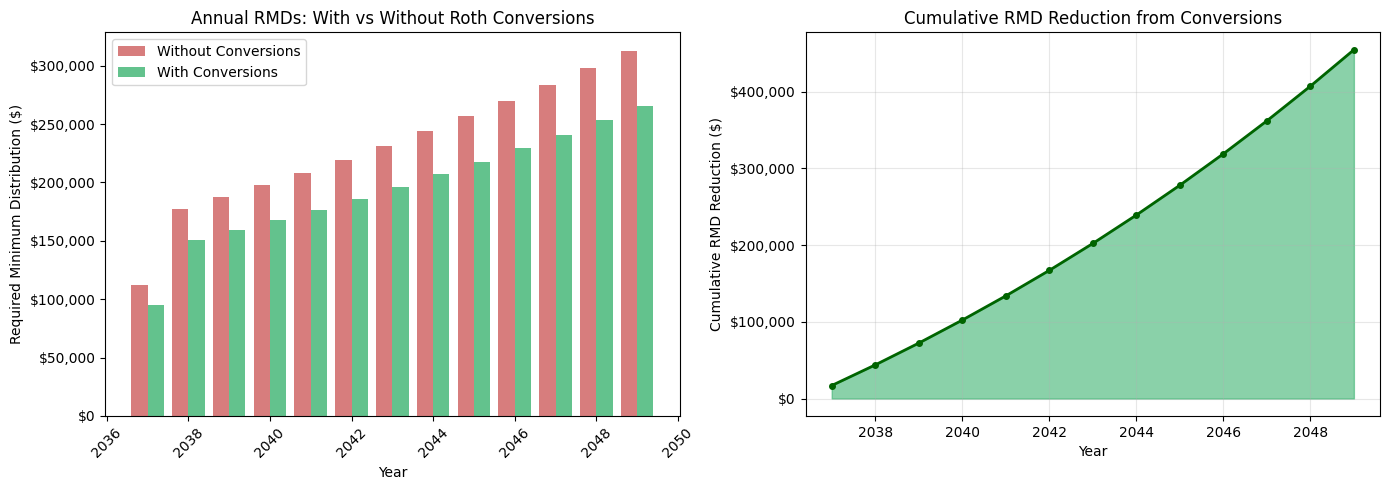


Chart saved as 'rmd_impact_analysis.png'


In [8]:
# Visualize RMD Impact
if len(rmd_years) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: RMD Comparison
    ax1 = axes[0]
    years = rmd_years['Year'].head(15)
    ax1.bar(years - 0.2, rmd_years['RMD_Without_Conversion'].head(15), 0.4, 
            label='Without Conversions', color='indianred', alpha=0.8)
    ax1.bar(years + 0.2, rmd_years['RMD_With_Conversion'].head(15), 0.4,
            label='With Conversions', color='mediumseagreen', alpha=0.8)
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Required Minimum Distribution ($)')
    ax1.set_title('Annual RMDs: With vs Without Roth Conversions')
    ax1.legend()
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # Plot 2: Cumulative RMD Reduction
    ax2 = axes[1]
    cumulative_reduction = rmd_years['Annual_RMD_Reduction'].cumsum()
    ax2.fill_between(rmd_years['Year'], 0, cumulative_reduction, 
                     alpha=0.6, color='mediumseagreen')
    ax2.plot(rmd_years['Year'], cumulative_reduction, 'o-', 
             color='darkgreen', linewidth=2, markersize=4)
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Cumulative RMD Reduction ($)')
    ax2.set_title('Cumulative RMD Reduction from Conversions')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('rmd_impact_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nChart saved as 'rmd_impact_analysis.png'")
else:
    print("No RMD chart - projection period doesn't reach RMD age.")

## 📊 Bracket Strategy Comparison

Compare the impact of filling different tax brackets: staying in current bracket, moving up one bracket, or moving up two brackets. This analysis shows whether the extra taxes paid now are worth the RMD reduction later.

In [ ]:
# =============================================================================
# BRACKET STRATEGY COMPARISON
# Compare: Current bracket, +1 bracket, +2 brackets
# =============================================================================

# Define the bracket progression for MFJ
BRACKET_ORDER = [0.10, 0.12, 0.22, 0.24, 0.32, 0.35, 0.37]

def get_next_brackets(current_bracket: float, steps: int = 1) -> float:
    """Get the bracket that is 'steps' higher than current."""
    try:
        current_idx = BRACKET_ORDER.index(current_bracket)
        new_idx = min(current_idx + steps, len(BRACKET_ORDER) - 1)
        return BRACKET_ORDER[new_idx]
    except ValueError:
        return current_bracket


def run_bracket_strategy(household: HouseholdProfile, target_bracket: float, 
                         years: int = 5, projection_years: int = 20) -> Dict:
    """Run a complete strategy for a given target bracket.
    
    Returns conversion plan, RMD projections, and summary metrics.
    """
    # Create a copy of household with new target bracket
    strategy_household = HouseholdProfile(
        spouse1=household.spouse1,
        spouse2=household.spouse2,
        joint_taxable_accounts=household.joint_taxable_accounts,
        work_income=household.work_income,
        pension_income=household.pension_income,
        other_income=household.other_income,
        state_tax_rate=household.state_tax_rate,
        expected_return=household.expected_return,
        inflation_rate=household.inflation_rate,
        target_bracket=target_bracket,
    )
    
    # Run 5-year conversion optimization
    plan = optimize_household_5_year(strategy_household, years=years)
    
    # Run RMD projection
    rmd_proj = project_rmd_comparison(strategy_household, plan, projection_years=projection_years)
    rmd_years_only = rmd_proj[rmd_proj['RMD_Without_Conversion'] > 0]
    
    # Calculate metrics
    total_converted = plan['Total_Conversion'].sum()
    total_conversion_tax = plan['Total_Tax'].sum()
    avg_conversion_rate = (total_conversion_tax / total_converted * 100) if total_converted > 0 else 0
    
    total_rmd_reduction = rmd_years_only['Annual_RMD_Reduction'].sum() if len(rmd_years_only) > 0 else 0
    
    # Estimate tax on reduced RMDs (use the target bracket as approximation)
    rmd_tax_savings = total_rmd_reduction * target_bracket
    
    # Net benefit = RMD tax savings - conversion taxes paid
    net_benefit = rmd_tax_savings - total_conversion_tax
    
    # Final balances
    final_pretax = plan['Total_PreTax'].iloc[-1]
    final_roth = plan['Total_Roth'].iloc[-1]
    
    return {
        'target_bracket': target_bracket,
        'bracket_pct': f"{int(target_bracket * 100)}%",
        'plan': plan,
        'rmd_projection': rmd_proj,
        'total_converted': total_converted,
        'total_conversion_tax': total_conversion_tax,
        'avg_conversion_rate': avg_conversion_rate,
        'total_rmd_reduction': total_rmd_reduction,
        'rmd_tax_savings': rmd_tax_savings,
        'net_benefit': net_benefit,
        'final_pretax': final_pretax,
        'final_roth': final_roth,
    }


def compare_bracket_strategies(household: HouseholdProfile) -> pd.DataFrame:
    """Compare current bracket, +1 bracket, and +2 bracket strategies."""
    
    # Determine current marginal bracket based on current income
    current_taxable = household.get_taxable_income_for_year(0)
    std_ded = household.get_standard_deduction(0)
    taxable = max(0, current_taxable - std_ded)
    
    # Find current bracket
    current_bracket = 0.10
    for limit, rate in TAX_BRACKETS_MFJ_2024:
        if taxable <= limit:
            current_bracket = rate
            break
    
    # Define strategies to compare
    strategies = {
        'No Conversion': 0.0,  # Special case
        f'Fill {int(current_bracket*100)}% (Current)': current_bracket,
        f'Fill {int(get_next_brackets(current_bracket, 1)*100)}% (+1 Bracket)': get_next_brackets(current_bracket, 1),
        f'Fill {int(get_next_brackets(current_bracket, 2)*100)}% (+2 Brackets)': get_next_brackets(current_bracket, 2),
    }
    
    results = []
    strategy_details = {}
    
    for name, bracket in strategies.items():
        if bracket == 0.0:
            # No conversion scenario
            results.append({
                'Strategy': name,
                'Target_Bracket': 'N/A',
                'Total_Converted': 0,
                'Conversion_Taxes': 0,
                'Avg_Conv_Rate': 0,
                'RMD_Reduction': 0,
                'Est_RMD_Tax_Savings': 0,
                'Net_Benefit': 0,
                'Final_PreTax': household.total_pretax * ((1 + household.expected_return) ** 5),
                'Final_Roth': household.total_roth * ((1 + household.expected_return) ** 5),
            })
        else:
            strategy = run_bracket_strategy(household, bracket)
            strategy_details[name] = strategy
            
            results.append({
                'Strategy': name,
                'Target_Bracket': strategy['bracket_pct'],
                'Total_Converted': strategy['total_converted'],
                'Conversion_Taxes': strategy['total_conversion_tax'],
                'Avg_Conv_Rate': strategy['avg_conversion_rate'],
                'RMD_Reduction': strategy['total_rmd_reduction'],
                'Est_RMD_Tax_Savings': strategy['rmd_tax_savings'],
                'Net_Benefit': strategy['net_benefit'],
                'Final_PreTax': strategy['final_pretax'],
                'Final_Roth': strategy['final_roth'],
            })
    
    return pd.DataFrame(results), strategy_details


# Run the comparison
print("=" * 100)
print("BRACKET STRATEGY COMPARISON")
print("=" * 100)
print("\nAnalyzing conversion strategies: Current bracket, +1 bracket, +2 brackets...")
print("This compares the cost of conversions now vs. the RMD tax savings later.\n")

comparison_df, strategy_details = compare_bracket_strategies(household)

# Display summary table
print("=" * 100)
print("STRATEGY SUMMARY (5-Year Conversion Period + 20-Year RMD Projection)")
print("=" * 100)
comparison_df

In [ ]:
# Detailed breakdown
print("\n" + "=" * 100)
print("DETAILED COMPARISON")
print("=" * 100)

for _, row in comparison_df.iterrows():
    print(f"\n📌 {row['Strategy']}")
    print(f"   Total Converted (5 years):     ${row['Total_Converted']:>12,.0f}")
    print(f"   Taxes Paid on Conversions:     ${row['Conversion_Taxes']:>12,.0f}  (avg {row['Avg_Conv_Rate']:.1f}%)")
    print(f"   RMD Reduction (20 years):      ${row['RMD_Reduction']:>12,.0f}")
    print(f"   Est. Tax Savings on RMDs:      ${row['Est_RMD_Tax_Savings']:>12,.0f}")
    print(f"   ─────────────────────────────────────────")
    print(f"   NET BENEFIT:                   ${row['Net_Benefit']:>12,.0f}  {'✅ GAIN' if row['Net_Benefit'] > 0 else '❌ LOSS' if row['Net_Benefit'] < 0 else ''}")

# Find the best strategy
best_strategy = comparison_df.loc[comparison_df['Net_Benefit'].idxmax()]
print("\n" + "=" * 100)
print(f"🏆 RECOMMENDED: {best_strategy['Strategy']}")
print(f"   This strategy provides the highest net benefit of ${best_strategy['Net_Benefit']:,.0f}")
print("=" * 100)

In [ ]:
# =============================================================================
# VISUALIZATION: Bracket Strategy Comparison
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

strategies = comparison_df['Strategy'].tolist()
x = np.arange(len(strategies))

# Plot 1: Conversion Amount vs Taxes Paid
ax1 = axes[0, 0]
width = 0.35
bars1 = ax1.bar(x - width/2, comparison_df['Total_Converted'], width, 
                label='Amount Converted', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, comparison_df['Conversion_Taxes'], width,
                label='Taxes Paid', color='indianred', alpha=0.8)
ax1.set_ylabel('Amount ($)')
ax1.set_title('5-Year Conversions: Amount vs Taxes')
ax1.set_xticks(x)
ax1.set_xticklabels([s.replace(' ', '\n') for s in strategies], fontsize=8)
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Plot 2: RMD Reduction & Tax Savings
ax2 = axes[0, 1]
bars3 = ax2.bar(x - width/2, comparison_df['RMD_Reduction'], width,
                label='RMD Reduction', color='mediumseagreen', alpha=0.8)
bars4 = ax2.bar(x + width/2, comparison_df['Est_RMD_Tax_Savings'], width,
                label='Est. Tax Savings', color='gold', alpha=0.8)
ax2.set_ylabel('Amount ($)')
ax2.set_title('20-Year RMD Impact')
ax2.set_xticks(x)
ax2.set_xticklabels([s.replace(' ', '\n') for s in strategies], fontsize=8)
ax2.legend()
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Plot 3: Net Benefit (the key chart!)
ax3 = axes[1, 0]
colors = ['gray' if v == 0 else ('green' if v > 0 else 'red') for v in comparison_df['Net_Benefit']]
bars5 = ax3.bar(x, comparison_df['Net_Benefit'], color=colors, alpha=0.8, edgecolor='black')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_ylabel('Net Benefit ($)')
ax3.set_title('💰 NET BENEFIT: RMD Tax Savings - Conversion Taxes')
ax3.set_xticks(x)
ax3.set_xticklabels([s.replace(' ', '\n') for s in strategies], fontsize=8)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Add value labels on net benefit bars
for bar, val in zip(bars5, comparison_df['Net_Benefit']):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'${val/1000:.0f}K',
             ha='center', va='bottom' if height >= 0 else 'top',
             fontsize=10, fontweight='bold')

# Plot 4: Final Account Balances
ax4 = axes[1, 1]
bars6 = ax4.bar(x - width/2, comparison_df['Final_PreTax'], width,
                label='Pre-Tax (will be taxed)', color='coral', alpha=0.8)
bars7 = ax4.bar(x + width/2, comparison_df['Final_Roth'], width,
                label='Roth (tax-free)', color='mediumseagreen', alpha=0.8)
ax4.set_ylabel('Balance After 5 Years ($)')
ax4.set_title('Final Account Balances')
ax4.set_xticks(x)
ax4.set_xticklabels([s.replace(' ', '\n') for s in strategies], fontsize=8)
ax4.legend()
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('bracket_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'bracket_strategy_comparison.png'")

In [ ]:
# =============================================================================
# YEAR-BY-YEAR COMPARISON ACROSS STRATEGIES
# =============================================================================

# Show annual conversion amounts for each strategy
print("=" * 100)
print("ANNUAL CONVERSION AMOUNTS BY STRATEGY")
print("=" * 100)

# Build comparison table
annual_comparison = pd.DataFrame({'Year': range(2025, 2030)})

for name, details in strategy_details.items():
    annual_comparison[name] = details['plan']['Total_Conversion'].values

print(annual_comparison.to_string(index=False, formatters={
    col: '${:,.0f}'.format for col in annual_comparison.columns if col != 'Year'
}))

# Calculate annual taxes for each strategy
print("\n" + "=" * 100)
print("ANNUAL TAXES BY STRATEGY")
print("=" * 100)

tax_comparison = pd.DataFrame({'Year': range(2025, 2030)})
for name, details in strategy_details.items():
    tax_comparison[name] = details['plan']['Total_Tax'].values

print(tax_comparison.to_string(index=False, formatters={
    col: '${:,.0f}'.format for col in tax_comparison.columns if col != 'Year'
}))

In [ ]:
# =============================================================================
# RMD COMPARISON CHART ACROSS STRATEGIES
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Get RMD projections for each strategy
colors = ['gray', 'steelblue', 'orange', 'green']
linestyles = ['-', '-', '--', ':']

for i, (name, details) in enumerate(strategy_details.items()):
    rmd_data = details['rmd_projection']
    rmd_with_conv = rmd_data[rmd_data['RMD_With_Conversion'] > 0]
    if len(rmd_with_conv) > 0:
        ax.plot(rmd_with_conv['Year'], rmd_with_conv['RMD_With_Conversion'], 
                label=name, color=colors[i+1], linestyle=linestyles[i+1], 
                linewidth=2, marker='o', markersize=4)

# Also plot "no conversion" scenario (RMD without conversion)
if len(strategy_details) > 0:
    first_strategy = list(strategy_details.values())[0]
    rmd_data = first_strategy['rmd_projection']
    rmd_no_conv = rmd_data[rmd_data['RMD_Without_Conversion'] > 0]
    if len(rmd_no_conv) > 0:
        ax.plot(rmd_no_conv['Year'], rmd_no_conv['RMD_Without_Conversion'],
                label='No Conversion', color='indianred', linestyle='-',
                linewidth=3, marker='s', markersize=5)

ax.set_xlabel('Year')
ax.set_ylabel('Required Minimum Distribution ($)')
ax.set_title('RMD Amounts Over Time: Impact of Different Conversion Strategies')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('rmd_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'rmd_strategy_comparison.png'")

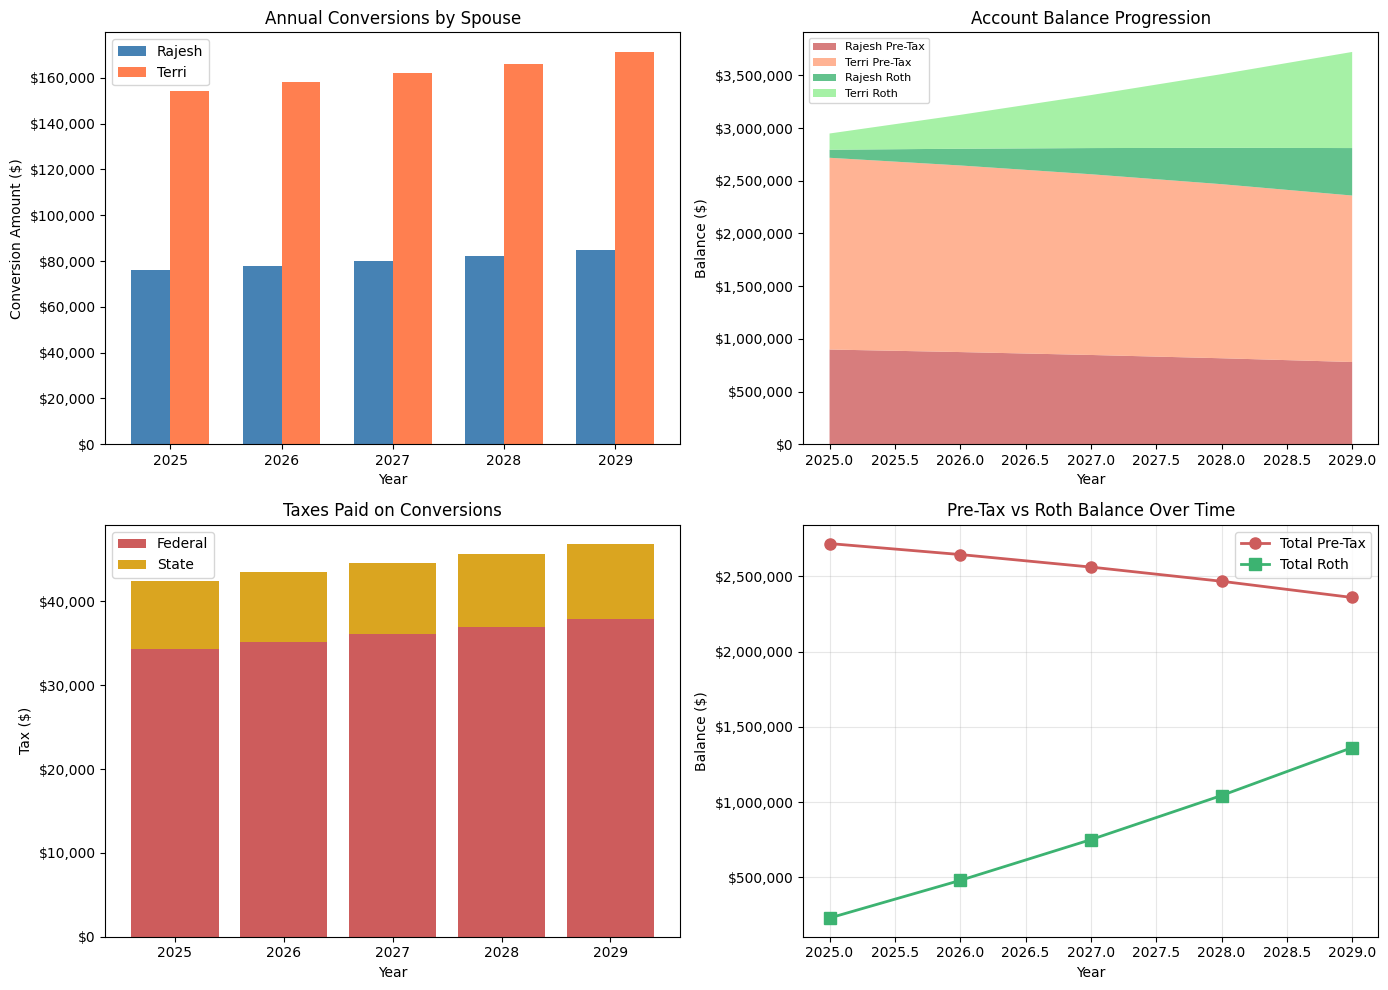


Chart saved as 'household_roth_analysis.png'


In [9]:
# Visualization for household
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Conversion amounts by spouse
ax1 = axes[0, 0]
width = 0.35
x = np.arange(len(household_plan))
ax1.bar(x - width/2, household_plan[f'{household.spouse1.name}_Conversion'], width, 
        label=household.spouse1.name, color='steelblue')
ax1.bar(x + width/2, household_plan[f'{household.spouse2.name}_Conversion'], width,
        label=household.spouse2.name, color='coral')
ax1.set_xlabel('Year')
ax1.set_ylabel('Conversion Amount ($)')
ax1.set_title('Annual Conversions by Spouse')
ax1.set_xticks(x)
ax1.set_xticklabels(household_plan['Calendar_Year'])
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 2: Account balance progression
ax2 = axes[0, 1]
years = household_plan['Calendar_Year']
ax2.stackplot(years, 
              household_plan[f'{household.spouse1.name}_PreTax'],
              household_plan[f'{household.spouse2.name}_PreTax'],
              household_plan[f'{household.spouse1.name}_Roth'],
              household_plan[f'{household.spouse2.name}_Roth'],
              labels=[f'{household.spouse1.name} Pre-Tax', f'{household.spouse2.name} Pre-Tax',
                     f'{household.spouse1.name} Roth', f'{household.spouse2.name} Roth'],
              colors=['indianred', 'lightsalmon', 'mediumseagreen', 'lightgreen'],
              alpha=0.8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Balance ($)')
ax2.set_title('Account Balance Progression')
ax2.legend(loc='upper left', fontsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 3: Taxes paid
ax3 = axes[1, 0]
ax3.bar(household_plan['Calendar_Year'], household_plan['Federal_Tax'], 
        label='Federal', color='indianred')
ax3.bar(household_plan['Calendar_Year'], household_plan['State_Tax'],
        bottom=household_plan['Federal_Tax'], label='State', color='goldenrod')
ax3.set_xlabel('Year')
ax3.set_ylabel('Tax ($)')
ax3.set_title('Taxes Paid on Conversions')
ax3.legend()
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 4: Pre-Tax vs Roth over time
ax4 = axes[1, 1]
ax4.plot(years, household_plan['Total_PreTax'], 'o-', label='Total Pre-Tax', 
         color='indianred', linewidth=2, markersize=8)
ax4.plot(years, household_plan['Total_Roth'], 's-', label='Total Roth',
         color='mediumseagreen', linewidth=2, markersize=8)
ax4.set_xlabel('Year')
ax4.set_ylabel('Balance ($)')
ax4.set_title('Pre-Tax vs Roth Balance Over Time')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('household_roth_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'household_roth_analysis.png'")

## Tax Calculation Functions

In [10]:
def calculate_federal_tax(taxable_income: float, brackets: List[Tuple[float, float]]) -> float:
    """Calculate federal income tax based on taxable income and brackets."""
    if taxable_income <= 0:
        return 0
    
    tax = 0
    prev_limit = 0
    
    for limit, rate in brackets:
        if taxable_income <= prev_limit:
            break
        
        taxable_in_bracket = min(taxable_income, limit) - prev_limit
        if taxable_in_bracket > 0:
            tax += taxable_in_bracket * rate
        
        prev_limit = limit
    
    return tax


def get_marginal_rate(taxable_income: float, brackets: List[Tuple[float, float]]) -> float:
    """Get the marginal tax rate for a given taxable income."""
    prev_limit = 0
    for limit, rate in brackets:
        if taxable_income <= limit:
            return rate
        prev_limit = limit
    return brackets[-1][1]


def calculate_total_tax(
    profile: TaxpayerProfile,
    conversion_amount: float,
    year: int = 0
) -> Tuple[float, float, float]:
    """Calculate total tax (federal + state) for a given conversion amount.
    
    Returns: (federal_tax, state_tax, total_tax)
    """
    # Get inflation-adjusted values
    standard_deduction = profile.get_standard_deduction(year)
    brackets = profile.get_tax_brackets(year)
    
    # Calculate adjusted other income for inflation
    other_income = profile.other_taxable_income * ((1 + profile.inflation_rate) ** year)
    
    # Total gross income
    gross_income = other_income + conversion_amount
    
    # Taxable income after standard deduction
    taxable_income = max(0, gross_income - standard_deduction)
    
    # Calculate federal tax
    federal_tax = calculate_federal_tax(taxable_income, brackets)
    
    # Calculate state tax (simplified - flat rate on taxable income)
    state_tax = taxable_income * profile.state_tax_rate
    
    total_tax = federal_tax + state_tax
    
    return federal_tax, state_tax, total_tax


# Test the tax calculation
test_conversion = 50000
fed_tax, state_tax, total_tax = calculate_total_tax(example_profile, test_conversion, 0)
print(f"Test conversion of ${test_conversion:,.0f}:")
print(f"  Federal Tax: ${fed_tax:,.2f}")
print(f"  State Tax: ${state_tax:,.2f}")
print(f"  Total Tax: ${total_tax:,.2f}")
print(f"  Effective Rate: {total_tax/test_conversion*100:.1f}%")

NameError: name 'example_profile' is not defined

## Optimal Conversion Amount Calculator
Find the optimal conversion amount to fill up to a target tax bracket.

In [ ]:
def find_bracket_top(
    profile: TaxpayerProfile,
    target_rate: float,
    year: int = 0
) -> float:
    """Find the income level at the top of the target bracket."""
    brackets = profile.get_tax_brackets(year)
    
    for limit, rate in brackets:
        if rate == target_rate:
            return limit
    
    # If target rate not found, return the limit just before the next higher rate
    prev_limit = 0
    for limit, rate in brackets:
        if rate > target_rate:
            return prev_limit
        prev_limit = limit
    
    return brackets[-2][0]  # Return second-to-last bracket limit


def calculate_optimal_conversion(
    profile: TaxpayerProfile,
    year: int = 0
) -> Dict:
    """Calculate the optimal Roth conversion amount to fill target bracket.
    
    Returns a dictionary with conversion details.
    """
    standard_deduction = profile.get_standard_deduction(year)
    brackets = profile.get_tax_brackets(year)
    
    # Inflation-adjusted other income
    other_income = profile.other_taxable_income * ((1 + profile.inflation_rate) ** year)
    
    # Current taxable income without conversion
    current_taxable = max(0, other_income - standard_deduction)
    current_marginal_rate = get_marginal_rate(current_taxable, brackets)
    
    # Find top of target bracket
    bracket_top = find_bracket_top(profile, profile.target_bracket, year)
    
    # Calculate optimal conversion to fill target bracket
    # Taxable income at bracket top
    target_taxable = bracket_top
    
    # Gross income needed to achieve target taxable income
    target_gross = target_taxable + standard_deduction
    
    # Optimal conversion amount
    optimal_conversion = max(0, target_gross - other_income)
    
    # Calculate taxes at optimal conversion
    fed_tax, state_tax, total_tax = calculate_total_tax(profile, optimal_conversion, year)
    
    return {
        'year': year,
        'calendar_year': 2024 + year,
        'other_income': other_income,
        'standard_deduction': standard_deduction,
        'current_taxable_income': current_taxable,
        'current_marginal_rate': current_marginal_rate,
        'target_bracket': profile.target_bracket,
        'bracket_top': bracket_top,
        'optimal_conversion': optimal_conversion,
        'federal_tax': fed_tax,
        'state_tax': state_tax,
        'total_tax': total_tax,
        'effective_tax_rate': total_tax / optimal_conversion if optimal_conversion > 0 else 0
    }


# Calculate optimal conversion for year 0
result = calculate_optimal_conversion(example_profile, 0)
print("Optimal Conversion Analysis for Year 1 (2024):")
print(f"  Other Income: ${result['other_income']:,.0f}")
print(f"  Standard Deduction: ${result['standard_deduction']:,.0f}")
print(f"  Current Marginal Rate: {result['current_marginal_rate']*100:.0f}%")
print(f"  Target Bracket: {result['target_bracket']*100:.0f}%")
print(f"  Optimal Conversion: ${result['optimal_conversion']:,.0f}")
print(f"  Total Tax on Conversion: ${result['total_tax']:,.0f}")
print(f"  Effective Rate: {result['effective_tax_rate']*100:.1f}%")

## 5-Year Roth Conversion Optimization

In [ ]:
def optimize_5_year_conversions(
    profile: TaxpayerProfile,
    years: int = 5
) -> pd.DataFrame:
    """Calculate optimal Roth conversions over multiple years.
    
    This tracks IRA balances and calculates year-by-year optimal conversions.
    """
    results = []
    
    # Track balances
    trad_balance = profile.traditional_ira_balance
    roth_balance = profile.roth_ira_balance
    total_taxes_paid = 0
    total_converted = 0
    
    for year in range(years):
        # Calculate optimal conversion for this year
        conversion_info = calculate_optimal_conversion(profile, year)
        
        # Cap conversion at available traditional IRA balance
        actual_conversion = min(conversion_info['optimal_conversion'], trad_balance)
        
        # Recalculate tax for actual conversion amount
        fed_tax, state_tax, total_tax = calculate_total_tax(profile, actual_conversion, year)
        
        # Update balances
        # Apply growth first (beginning of year)
        trad_balance *= (1 + profile.expected_return)
        roth_balance *= (1 + profile.expected_return)
        
        # Then do conversion (end of year)
        trad_balance -= actual_conversion
        roth_balance += actual_conversion
        
        total_taxes_paid += total_tax
        total_converted += actual_conversion
        
        results.append({
            'Year': year + 1,
            'Calendar_Year': 2024 + year,
            'Age': profile.age + year,
            'Other_Income': conversion_info['other_income'],
            'Conversion_Amount': actual_conversion,
            'Federal_Tax': fed_tax,
            'State_Tax': state_tax,
            'Total_Tax': total_tax,
            'Effective_Rate': (total_tax / actual_conversion * 100) if actual_conversion > 0 else 0,
            'Trad_IRA_Balance': trad_balance,
            'Roth_IRA_Balance': roth_balance,
            'Cumulative_Converted': total_converted,
            'Cumulative_Taxes': total_taxes_paid
        })
    
    df = pd.DataFrame(results)
    return df


# Run the 5-year optimization
conversion_plan = optimize_5_year_conversions(example_profile, years=5)
print("5-Year Roth Conversion Plan")
print("=" * 80)
conversion_plan

In [ ]:
# Summary statistics
print("\n" + "=" * 60)
print("5-YEAR ROTH CONVERSION SUMMARY")
print("=" * 60)
print(f"\nInitial Traditional IRA Balance: ${example_profile.traditional_ira_balance:,.0f}")
print(f"Initial Roth IRA Balance: ${example_profile.roth_ira_balance:,.0f}")
print(f"\nTotal Amount Converted: ${conversion_plan['Conversion_Amount'].sum():,.0f}")
print(f"Total Taxes Paid: ${conversion_plan['Total_Tax'].sum():,.0f}")
print(f"Average Effective Tax Rate: {conversion_plan['Effective_Rate'].mean():.1f}%")
print(f"\nFinal Traditional IRA Balance: ${conversion_plan['Trad_IRA_Balance'].iloc[-1]:,.0f}")
print(f"Final Roth IRA Balance: ${conversion_plan['Roth_IRA_Balance'].iloc[-1]:,.0f}")
print(f"Final Total IRA Balance: ${conversion_plan['Trad_IRA_Balance'].iloc[-1] + conversion_plan['Roth_IRA_Balance'].iloc[-1]:,.0f}")

## Visualization

In [ ]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Conversion amounts by year
ax1 = axes[0, 0]
ax1.bar(conversion_plan['Calendar_Year'], conversion_plan['Conversion_Amount'], 
        color='steelblue', edgecolor='navy')
ax1.set_xlabel('Year')
ax1.set_ylabel('Conversion Amount ($)')
ax1.set_title('Annual Roth Conversion Amounts')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
for i, v in enumerate(conversion_plan['Conversion_Amount']):
    ax1.text(conversion_plan['Calendar_Year'].iloc[i], v + 2000, f'${v:,.0f}', 
             ha='center', va='bottom', fontsize=9)

# Plot 2: IRA Balance Progression
ax2 = axes[0, 1]
years = conversion_plan['Calendar_Year']
ax2.fill_between(years, 0, conversion_plan['Trad_IRA_Balance'], 
                 alpha=0.7, label='Traditional IRA', color='coral')
ax2.fill_between(years, conversion_plan['Trad_IRA_Balance'], 
                 conversion_plan['Trad_IRA_Balance'] + conversion_plan['Roth_IRA_Balance'],
                 alpha=0.7, label='Roth IRA', color='mediumseagreen')
ax2.set_xlabel('Year')
ax2.set_ylabel('Balance ($)')
ax2.set_title('IRA Balance Progression')
ax2.legend(loc='upper right')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 3: Taxes paid by year
ax3 = axes[1, 0]
width = 0.35
x = np.arange(len(years))
ax3.bar(x - width/2, conversion_plan['Federal_Tax'], width, label='Federal Tax', color='indianred')
ax3.bar(x + width/2, conversion_plan['State_Tax'], width, label='State Tax', color='goldenrod')
ax3.set_xlabel('Year')
ax3.set_ylabel('Tax Amount ($)')
ax3.set_title('Taxes Paid on Conversions')
ax3.set_xticks(x)
ax3.set_xticklabels(years)
ax3.legend()
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 4: Cumulative conversions and taxes
ax4 = axes[1, 1]
ax4.plot(years, conversion_plan['Cumulative_Converted'], 'o-', 
         label='Cumulative Converted', color='steelblue', linewidth=2, markersize=8)
ax4.plot(years, conversion_plan['Cumulative_Taxes'], 's-', 
         label='Cumulative Taxes', color='indianred', linewidth=2, markersize=8)
ax4.set_xlabel('Year')
ax4.set_ylabel('Amount ($)')
ax4.set_title('Cumulative Conversions vs Taxes Paid')
ax4.legend()
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roth_conversion_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'roth_conversion_analysis.png'")

## Advanced Optimization: Minimize Lifetime Taxes

This section uses optimization to find the best conversion amounts that minimize total lifetime taxes, considering future RMDs and growth.

In [ ]:
def calculate_rmd_factor(age: int) -> float:
    """Get the RMD distribution period based on age (Uniform Lifetime Table)."""
    # Simplified RMD factors - starts at age 73
    rmd_table = {
        73: 26.5, 74: 25.5, 75: 24.6, 76: 23.7, 77: 22.9,
        78: 22.0, 79: 21.1, 80: 20.2, 81: 19.4, 82: 18.5,
        83: 17.7, 84: 16.8, 85: 16.0, 86: 15.2, 87: 14.4,
        88: 13.7, 89: 12.9, 90: 12.2, 91: 11.5, 92: 10.8,
        93: 10.1, 94: 9.5, 95: 8.9, 96: 8.4, 97: 7.8,
        98: 7.3, 99: 6.8, 100: 6.4
    }
    if age < 73:
        return 0  # No RMD required
    if age > 100:
        return 6.4
    return rmd_table.get(age, 6.4)


def project_lifetime_taxes(
    profile: TaxpayerProfile,
    conversion_amounts: List[float],
    projection_years: int = 30
) -> Dict:
    """Project lifetime taxes with given conversion strategy.
    
    Args:
        profile: Taxpayer profile
        conversion_amounts: List of conversion amounts for each year
        projection_years: Years to project (default 30)
    
    Returns:
        Dictionary with projection results
    """
    trad_balance = profile.traditional_ira_balance
    roth_balance = profile.roth_ira_balance
    
    total_conversion_taxes = 0
    total_rmd_taxes = 0
    yearly_data = []
    
    conversion_years = len(conversion_amounts)
    
    for year in range(projection_years):
        age = profile.age + year
        
        # Apply growth
        trad_balance *= (1 + profile.expected_return)
        roth_balance *= (1 + profile.expected_return)
        
        # Determine conversion (only during conversion period)
        if year < conversion_years:
            conversion = min(conversion_amounts[year], max(0, trad_balance))
        else:
            conversion = 0
        
        # Calculate RMD (if applicable)
        rmd_factor = calculate_rmd_factor(age)
        if rmd_factor > 0:
            rmd = trad_balance / rmd_factor
        else:
            rmd = 0
        
        # Total taxable distribution
        total_distribution = conversion + rmd
        
        # Calculate taxes
        _, _, tax = calculate_total_tax(profile, total_distribution, year)
        
        # Allocate taxes between conversion and RMD
        if total_distribution > 0:
            conversion_tax = tax * (conversion / total_distribution)
            rmd_tax = tax * (rmd / total_distribution)
        else:
            conversion_tax = 0
            rmd_tax = 0
        
        total_conversion_taxes += conversion_tax
        total_rmd_taxes += rmd_tax
        
        # Update balances
        trad_balance -= (conversion + rmd)
        roth_balance += conversion  # RMD is withdrawn, not converted
        
        yearly_data.append({
            'year': year,
            'age': age,
            'trad_balance': trad_balance,
            'roth_balance': roth_balance,
            'conversion': conversion,
            'rmd': rmd,
            'tax': tax
        })
    
    return {
        'total_conversion_taxes': total_conversion_taxes,
        'total_rmd_taxes': total_rmd_taxes,
        'total_lifetime_taxes': total_conversion_taxes + total_rmd_taxes,
        'final_trad_balance': trad_balance,
        'final_roth_balance': roth_balance,
        'yearly_data': yearly_data
    }


# Test with current strategy
current_conversions = conversion_plan['Conversion_Amount'].tolist()
projection = project_lifetime_taxes(example_profile, current_conversions, 30)

print("30-Year Projection with Current Strategy:")
print(f"  Total Conversion Taxes: ${projection['total_conversion_taxes']:,.0f}")
print(f"  Total RMD Taxes: ${projection['total_rmd_taxes']:,.0f}")
print(f"  Total Lifetime Taxes: ${projection['total_lifetime_taxes']:,.0f}")

In [ ]:
def optimize_conversions_scipy(
    profile: TaxpayerProfile,
    years: int = 5,
    projection_years: int = 30
) -> Tuple[List[float], Dict]:
    """Use scipy optimization to find optimal conversion amounts."""
    
    def objective(conversions):
        """Objective function to minimize total lifetime taxes."""
        result = project_lifetime_taxes(profile, list(conversions), projection_years)
        return result['total_lifetime_taxes']
    
    # Initial guess: equal conversions over the period
    initial_guess = [profile.traditional_ira_balance / years] * years
    
    # Bounds: 0 to full balance for each year
    bounds = [(0, profile.traditional_ira_balance) for _ in range(years)]
    
    # Use differential evolution for global optimization
    result = differential_evolution(
        objective,
        bounds,
        seed=42,
        maxiter=200,
        tol=100,
        workers=-1,
        updating='deferred'
    )
    
    optimal_conversions = list(result.x)
    optimal_projection = project_lifetime_taxes(profile, optimal_conversions, projection_years)
    
    return optimal_conversions, optimal_projection


print("Running optimization (this may take a moment)...")
optimal_conversions, optimal_result = optimize_conversions_scipy(example_profile, years=5)

print("\nOptimized 5-Year Conversion Strategy:")
print("=" * 50)
for i, conv in enumerate(optimal_conversions):
    print(f"  Year {i+1} ({2024+i}): ${conv:,.0f}")

print(f"\nTotal Converted: ${sum(optimal_conversions):,.0f}")
print(f"Lifetime Taxes (Optimized): ${optimal_result['total_lifetime_taxes']:,.0f}")
print(f"Lifetime Taxes (Bracket-Fill): ${projection['total_lifetime_taxes']:,.0f}")
print(f"Tax Savings: ${projection['total_lifetime_taxes'] - optimal_result['total_lifetime_taxes']:,.0f}")

## Comparison: Different Strategies

In [ ]:
def compare_strategies(profile: TaxpayerProfile) -> pd.DataFrame:
    """Compare different Roth conversion strategies."""
    strategies = {}
    
    # Strategy 1: No conversions
    no_conversion = project_lifetime_taxes(profile, [0, 0, 0, 0, 0], 30)
    strategies['No Conversion'] = no_conversion
    
    # Strategy 2: Fill 12% bracket
    profile_12 = TaxpayerProfile(**{**profile.__dict__, 'target_bracket': 0.12})
    plan_12 = optimize_5_year_conversions(profile_12, 5)
    result_12 = project_lifetime_taxes(profile, plan_12['Conversion_Amount'].tolist(), 30)
    strategies['Fill 12% Bracket'] = result_12
    
    # Strategy 3: Fill 22% bracket (current)
    result_22 = project_lifetime_taxes(profile, current_conversions, 30)
    strategies['Fill 22% Bracket'] = result_22
    
    # Strategy 4: Fill 24% bracket
    profile_24 = TaxpayerProfile(**{**profile.__dict__, 'target_bracket': 0.24})
    plan_24 = optimize_5_year_conversions(profile_24, 5)
    result_24 = project_lifetime_taxes(profile, plan_24['Conversion_Amount'].tolist(), 30)
    strategies['Fill 24% Bracket'] = result_24
    
    # Strategy 5: Optimized (from scipy)
    strategies['Optimized'] = optimal_result
    
    # Create comparison dataframe
    comparison_data = []
    for name, result in strategies.items():
        comparison_data.append({
            'Strategy': name,
            'Conversion_Taxes': result['total_conversion_taxes'],
            'RMD_Taxes': result['total_rmd_taxes'],
            'Total_Lifetime_Taxes': result['total_lifetime_taxes'],
            'Final_Roth_Balance': result['final_roth_balance'],
            'Final_Trad_Balance': result['final_trad_balance']
        })
    
    df = pd.DataFrame(comparison_data)
    df['Tax_Savings_vs_NoConversion'] = df['Total_Lifetime_Taxes'].iloc[0] - df['Total_Lifetime_Taxes']
    
    return df


comparison_df = compare_strategies(example_profile)
print("Strategy Comparison (30-Year Projection)")
print("=" * 80)
comparison_df

In [ ]:
# Visualize strategy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total lifetime taxes by strategy
ax1 = axes[0]
colors = ['lightcoral', 'lightsalmon', 'khaki', 'lightgreen', 'mediumseagreen']
bars = ax1.barh(comparison_df['Strategy'], comparison_df['Total_Lifetime_Taxes'], color=colors)
ax1.set_xlabel('Total Lifetime Taxes ($)')
ax1.set_title('30-Year Lifetime Tax Comparison')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Add value labels
for bar, val in zip(bars, comparison_df['Total_Lifetime_Taxes']):
    ax1.text(val + 2000, bar.get_y() + bar.get_height()/2, 
             f'${val:,.0f}', va='center', fontsize=9)

# Plot 2: Final account balances
ax2 = axes[1]
x = np.arange(len(comparison_df))
width = 0.35
ax2.barh(x - width/2, comparison_df['Final_Trad_Balance'], width, 
         label='Traditional IRA', color='coral')
ax2.barh(x + width/2, comparison_df['Final_Roth_Balance'], width, 
         label='Roth IRA', color='mediumseagreen')
ax2.set_yticks(x)
ax2.set_yticklabels(comparison_df['Strategy'])
ax2.set_xlabel('Final Balance ($)')
ax2.set_title('Final IRA Balances After 30 Years')
ax2.legend()
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'strategy_comparison.png'")

## Interactive Configuration

Modify the profile below to analyze your own situation:

In [ ]:
# =============================================================================
# MODIFY YOUR PROFILE HERE
# =============================================================================

my_profile = TaxpayerProfile(
    name="Your Name",
    age=60,                           # Your current age
    filing_status='mfj',              # 'mfj' (married filing jointly) or 'single'
    traditional_ira_balance=400000,   # Your Traditional IRA balance
    roth_ira_balance=50000,           # Your Roth IRA balance
    other_taxable_income=50000,       # Other income (Social Security, pension, wages)
    state_tax_rate=0.05,              # Your state tax rate (0 if no state tax)
    expected_return=0.06,             # Expected investment return (6% = 0.06)
    inflation_rate=0.025,             # Expected inflation (2.5% = 0.025)
    target_bracket=0.22,              # Target tax bracket to fill
    spouse_age=58                     # Spouse age (if married)
)

# Run analysis
print(f"Analyzing profile for: {my_profile.name}")
print("=" * 60)

my_plan = optimize_5_year_conversions(my_profile, years=5)
print("\n5-Year Conversion Plan:")
display(my_plan[['Calendar_Year', 'Age', 'Conversion_Amount', 'Total_Tax', 'Effective_Rate', 
                 'Trad_IRA_Balance', 'Roth_IRA_Balance']])

print(f"\nTotal to Convert: ${my_plan['Conversion_Amount'].sum():,.0f}")
print(f"Total Taxes: ${my_plan['Total_Tax'].sum():,.0f}")
print(f"Average Effective Rate: {my_plan['Effective_Rate'].mean():.1f}%")

## Key Considerations & Disclaimers

### Important Notes:
1. **This is for educational purposes only** - Consult a qualified tax professional before making any conversion decisions
2. **Tax laws change** - Brackets and rules may be different in future years
3. **IRMAA implications** - Large conversions may increase Medicare premiums
4. **State taxes vary** - Some states don't tax retirement income
5. **Pro-rata rule** - If you have non-deductible Traditional IRA contributions, calculations will differ
6. **Capital gains** - Consider impact on investment income taxation
7. **Estate planning** - Roth conversions can be beneficial for heirs

### Factors Not Included in This Model:
- Medicare IRMAA surcharges
- Social Security taxation thresholds
- Net Investment Income Tax (NIIT)
- State-specific retirement income exclusions
- ACA subsidy impacts
- Estate tax considerations